In [ ]:
import ccxt
import numpy as np  
from sklearn import linear_model,metrics
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [ ]:
#Return
def ret(xau,xag):
    xag_r=[]
    xau_r=[]
    for i in range(1,len(xau)):
        xag_r.append(((xau[i]-xau[i-1])/xau[i-1])*100)
        xau_r.append(((xag[i]-xag[i-1])/xag[i-1])*100)
    return xau_r,xag_r

In [ ]:
#XAG Price
def XAG_PRICE(exchange):
    time.sleep(1)
    ticker=exchange.fetch_ohlcv("XAGUSDT",timeframe="1m",limit=1)
    return ticker[0][4]

In [ ]:
#XAU Price
def XAU_PRICE(exchange):
    ticker=exchange.fetch_ohlcv("XAUUSDT",timeframe="1m",limit=1)
    return ticker[0][4]


R Square: 0.027592674125851535


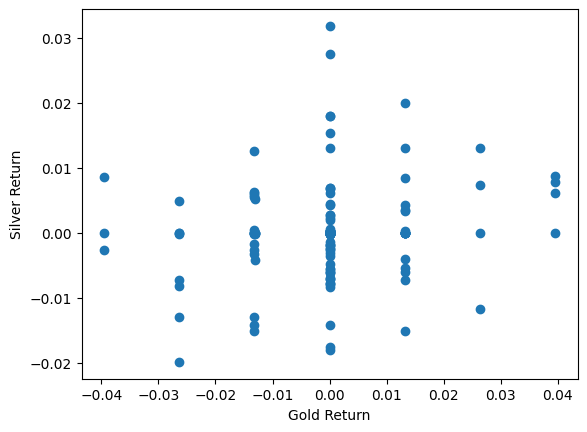

Iteration: 148


IndexError: list assignment index out of range

In [ ]:
#main function
def main():
    exchange=ccxt.binance()
    xau=[]
    xag=[]
    ite=0
    r_square=[]
    while True:       
        if len(xau)<149:
            xau.append(XAU_PRICE(exchange))
            xag.append(XAG_PRICE(exchange))
        else:
            for i in range(0,len(xau)-1):
                xau[i]=xau[i+1]
                xag[i]=xau[i+1]
            xau[149]=XAU_PRICE(exchange)
            xag[149]=XAG_PRICE(exchange)
        x_ret=ret(xau,xag)
        xau_ret=x_ret[0]
        xag_ret=x_ret[1]
        if len(xau_ret)>0 and len(xag_ret)>1:
            model=linear_model.LinearRegression()
            model.fit(np.array(xau_ret).reshape(-1,1),np.array(xag_ret))
            r_square=metrics.r2_score(np.array(xag_ret),model.predict(np.array(xau_ret).reshape(-1,1)))
        clear_output(wait=False)
        print("R Square:",r_square)
        plt.scatter(xau_ret,xag_ret)
        plt.xlabel("Gold Return")
        plt.ylabel("Silver Return")
        plt.show()
        print("Iteration:",ite)
        ite=ite+1
        
        
main()